In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import math
import seaborn as sns
import gc
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
import time
import pickle
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load Data

In [ ]:
train_transaction = pd.read_csv('./dataset/train_transaction.csv')
train_identity = pd.read_csv('./dataset/train_identity.csv')
test_transaction = pd.read_csv('./dataset/test_transaction.csv')
TransactionID = test_transaction['TransactionID']
test_identity = pd.read_csv('./dataset/test_identity.csv')

In [4]:
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
print(f"train shape: {df.shape}")
df_test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')
print(f"test shape: {df_test.shape}")

train shape: (590540, 434)
test shape: (506691, 433)


# Eksperimen PCA

In [ ]:
categorical_cols = train_identity.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    train_identity[col] = train_identity[col].fillna('null')
    test_identity[col] = test_identity[col].fillna('null')

for col in train_identity.select_dtypes(include=np.number).columns:
    train_identity[col] = train_identity[col].fillna(-999)
    test_identity[col] = test_identity[col].fillna(-999)

encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    dff = pd.concat([train_identity[col]], axis=0).sort_values().unique()
    encoder.fit(dff)
    # encoder.fit(pd.concat([train[col], test[col]], axis=0).unique())

    train_identity[col] = encoder.transform(train_identity[col])

    encoders[col] = encoder
    
# Perform PCA
pca = PCA(n_components=1)
pca_result = pca.fit_transform(train_identity.iloc[:, 1:])

# Add the PCA result as a new column to the original DataFrame
train_identity['PCA_1'] = None
train_identity.loc[train_identity.index, 'PCA_1'] = pca_result[:, 0]

# train_identity['PCA_1'].head()
pca1 = train_identity['PCA_1']
# train_identity = pd.read_csv('./dataset/train_identity.csv')
train_identity['PCA_1'] = pca1
train_identity

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,PCA_1
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,-99835.254182
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device,-71676.903723
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,F,F,T,T,desktop,Windows,21009.222251
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,F,F,T,T,desktop,NaN,51211.720515
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS,-163163.225592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144228,3577521,-15.0,145955.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,F,F,T,F,mobile,F3111 Build/33.3.A.1.97,-24666.218164
144229,3577526,-5.0,172059.0,NaN,NaN,1.0,-5.0,NaN,NaN,NaN,...,32.0,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F,1437.45955
144230,3577529,-20.0,632381.0,NaN,NaN,-1.0,-36.0,NaN,NaN,NaN,...,NaN,NaN,NaN,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152,461760.372485
144231,3577531,-5.0,55528.0,0.0,0.0,0.0,-7.0,NaN,NaN,0.0,...,24.0,2560x1600,match_status:2,T,F,T,F,desktop,MacOS,-115095.038975


In [ ]:
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
print(f"train shape: {df.shape}")
df_test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')
print(f"test shape: {df_test.shape}")

In [16]:
merged_counts = pd.merge(trans_counts, fraud_counts, on='PCA_1', how='inner')
merged_counts = merged_counts.sort_values(by='fraud_counts', ascending=False)
merged_counts.head(10)

,PCA_1,counts,fraud_counts
2,-171620.520413,481,38
1,-171620.518379,673,28
0,-171620.520413,1984,20
3,-171620.510584,38,8
6,-170098.147534,3,3
15,-169716.148186,2,2
25,-170380.147053,2,2
24,-170361.220901,2,2
23,-85278.541193,2,2
21,-168870.770580,2,2


In [5]:
print(df.shape)
print(train_transaction.shape)
print(train_identity.shape)

(590540, 434)
(590540, 394)
(144233, 41)


In [12]:
indices = [295456,295457,453414,453415,570433,570434]
df.iloc[indices]

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
295456,3282456,0,7310775,47.95,W,7919,194.0,150.0,mastercard,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
295457,3282457,0,7310775,47.95,W,7919,194.0,150.0,mastercard,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
453414,3440414,0,11576951,512.95,W,1359,314.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
453415,3440415,0,11576951,512.95,W,1359,314.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
570433,3557433,0,15129302,44.00,W,2744,490.0,150.0,visa,195.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
570434,3557434,0,15129302,44.00,W,2744,490.0,150.0,visa,195.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_test.columns = df_test.columns.str.replace('^id-', 'id_', regex=True)    # replace id- to id_
df = df[df['TransactionAmt'] <= 20000] # drop outlier
print(df.shape)
print(df_test.shape)
# Drop the columns with too many missing values
drop_column = ['id_07','id_21', 'id_22', 'id_23','id_24', 'id_25', 'id_26', 'id_27', 'TransactionID']   # drop columns
# drop_column = ['TransactionID']
df.drop(drop_column, axis=1, inplace=True)
df_test.drop(drop_column, axis=1, inplace=True)

indices = [295457,453415,570434]
df.iloc[indices]

# Drop the rows with the specified indices
df = df.drop(indices).reset_index(drop=True)

#drop outlier
df = df[df['TransactionAmt'] <= 20000]

print("after drop")
print(df.shape)
print(df_test.shape)

(590540, 434)
(506691, 433)
after drop
(590535, 425)
(506691, 424)


In [16]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)

for col in categorical_cols:
    df[col] = df[col].fillna('null')
for col in categorical_cols:
    df_test[col] = df_test[col].fillna('null')

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(-999)

for col in df_test.select_dtypes(include=np.number).columns:
    df_test[col] = df_test[col].fillna(-999)

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15',
       'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35',
       'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo'],
      dtype='object')


In [17]:
encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    dff = pd.concat([df[col],df_test[col]], axis=0).sort_values().unique()
    encoder.fit(dff)
    # encoder.fit(pd.concat([train[col], test[col]], axis=0).unique())

    df[col] = encoder.transform(df[col])
    df_test[col] = encoder.transform(df_test[col])

    if df[col].max() > 32000 or df_test[col].max() > 32000:
        df[col] = df[col].astype('int32')
        df_test[col] = df_test[col].astype('int32')
    else:
        df[col] = df[col].astype('int16')
        df_test[col] = df_test[col].astype('int16')

    encoders[col] = encoder

# Preprocessing

In [2]:
# load data
train_transaction = pd.read_csv('./dataset/train_transaction.csv')
train_identity = pd.read_csv('./dataset/train_identity.csv')
test_transaction = pd.read_csv('./dataset/test_transaction.csv')
test_identity = pd.read_csv('./dataset/test_identity.csv')

# merge data
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
df_test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

#ubah nama kolom
df_test.columns = df_test.columns.str.replace('^id-', 'id_', regex=True)    # replace id- to id_

#drop kolom
drop_column = ['id_07','id_21', 'id_22', 'id_23','id_24', 'id_25', 'id_26', 'id_27', 'TransactionID']
df.drop(drop_column, axis=1, inplace=True)
df_test.drop(drop_column, axis=1, inplace=True)

#ubah missing values
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)
for col in categorical_cols:
    df[col] = df[col].fillna('null')
for col in categorical_cols:
    df_test[col] = df_test[col].fillna('null')

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(-999)

for col in df_test.select_dtypes(include=np.number).columns:
    df_test[col] = df_test[col].fillna(-999)

#ubah ke numerik
encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    dff = pd.concat([df[col],df_test[col]], axis=0).sort_values().unique()
    encoder.fit(dff)
    # encoder.fit(pd.concat([train[col], test[col]], axis=0).unique())

    df[col] = encoder.transform(df[col])
    df_test[col] = encoder.transform(df_test[col])

    if df[col].max() > 32000 or df_test[col].max() > 32000:
        df[col] = df[col].astype('int32')
        df_test[col] = df_test[col].astype('int32')
    else:
        df[col] = df[col].astype('int16')
        df_test[col] = df_test[col].astype('int16')
    encoders[col] = encoder

#persiapan split data
x = df.drop('isFraud', axis=1)
y = df['isFraud']

#normalisasi data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x.astype(np.float32))
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)
test_scaled = scaler.fit_transform(df_test.astype(np.float32))
test_scaled = pd.DataFrame(test_scaled, columns=df_test.columns)

#split data
x_train, x_val, y_train, y_val = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)


Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15',
       'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35',
       'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo'],
      dtype='object')


# Modeling

## Split Data

In [4]:
x = df.drop('isFraud', axis=1)
y = df['isFraud']

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x.astype(np.float32))
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

test_scaled = scaler.fit_transform(df_test.astype(np.float32))
test_scaled = pd.DataFrame(test_scaled, columns=df_test.columns)

x_train, x_val, y_train, y_val = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)
result_list = []

## XGB

In [19]:
# Initialize and train the XGBoost model
model = xgb.XGBClassifier(random_state=42)  # You can customize hyperparameters here
# model = xgb.XGBClassifier(
#     learning_rate=0.1,  
#     max_depth=3,        
#     n_estimators=100,   
#     random_state=42
# )

# {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}
model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob = model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred = model.predict(x_val)

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_val, y_pred_prob)
print(f"AUC-ROC score: {auc_roc}")
print(classification_report(y_val, y_pred))

# Create and display the confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

result_list.append(
    {
        'model': 'XGBoost',
        'params': model.get_xgb_params(),
        'auc_roc': auc_roc,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_val, y_pred, output_dict=True)
    }
)

AUC-ROC score: 0.9417680628159615
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113974
           1       0.91      0.51      0.65      4133

    accuracy                           0.98    118107
   macro avg       0.95      0.75      0.82    118107
weighted avg       0.98      0.98      0.98    118107

Confusion Matrix:
[[113779    195]
 [  2045   2088]]


In [20]:
model = xgb.XGBClassifier(
    learning_rate=0.1,  
    max_depth=9,        
    n_estimators=200,   
    random_state=42
)

# params =  {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}
model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob = model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred = model.predict(x_val)

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_val, y_pred_prob)
print(f"AUC-ROC score: {auc_roc}")
print(classification_report(y_val, y_pred))

# Create and display the confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

result_list.append(
    {
        'model': 'XGBoost tuning',
        'params': model.get_xgb_params(),
        'auc_roc': auc_roc,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_val, y_pred, output_dict=True)
    }
)

AUC-ROC score: 0.9595757650076961
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113974
           1       0.95      0.55      0.69      4133

    accuracy                           0.98    118107
   macro avg       0.97      0.77      0.84    118107
weighted avg       0.98      0.98      0.98    118107

Confusion Matrix:
[[113848    126]
 [  1865   2268]]


In [ ]:
model = xgb.XGBClassifier(
    learning_rate=0.01,  
    max_depth=15,        
    n_estimators=5000,   
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='gpu_hist',
)

# params =  {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}
model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob = model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred = model.predict(x_val)

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_val, y_pred_prob)
print(f"AUC-ROC score: {auc_roc}")
print(classification_report(y_val, y_pred))

# Create and display the confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

result_list.append(
    {
        'model': 'XGBoost tuning 2',
        'params': model.get_xgb_params(),
        'auc_roc': auc_roc,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_val, y_pred, output_dict=True)
    }
)

## LightGBM

In [21]:
import lightgbm as lgb

# Initialize the LightGBM model
lgb_model = lgb.LGBMClassifier(random_state=42)

# Train the model
lgb_model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob_lgb = lgb_model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred_lgb = lgb_model.predict(x_val)

# Calculate AUC-ROC score
auc_roc_lgb = roc_auc_score(y_val, y_pred_prob_lgb)
print(f"AUC-ROC score: {auc_roc_lgb}")
print(classification_report(y_val, y_pred_lgb))

# Create and display the confusion matrix
cm_lgb = confusion_matrix(y_val, y_pred_lgb)
print("Confusion Matrix:")
print(cm_lgb)

# Append results to the result list
result_list.append(
    {
        'model': 'LightGBM',
        'params': lgb_model.get_params(),
        'auc_roc': auc_roc_lgb,
        'confusion_matrix': cm_lgb,
        'classification_report': classification_report(y_val, y_pred_lgb, output_dict=True)
    }
)

[LightGBM] [Info] Number of positive: 16530, number of negative: 455898
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.549635 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38225
[LightGBM] [Info] Number of data points in the train set: 472428, number of used features: 423
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317092
[LightGBM] [Info] Start training from score -3.317092
AUC-ROC score: 0.9287648032061648
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113974
           1       0.90      0.43      0.58      4133

    accuracy                           0.98    118107
   macro avg       0.94      0.71      0.79    118107
weighted avg       0.98      0.98      0.97    118107

Confusion Matrix:
[[113768    206]
 [  2353   1780]]


In [6]:
import lightgbm as lgb

# Initialize the LightGBM model
lgb_model = lgb.LGBMClassifier(
    learning_rate=0.01,  
    max_depth=12,        
    n_estimators=10000,   
    bagging_fraction=0.8,
    feature_fraction=0.4,
    boosting_type= 'gbdt',
)

# Train the model
lgb_model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob_lgb = lgb_model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred_lgb = lgb_model.predict(x_val)

# Calculate AUC-ROC score
auc_roc_lgb = roc_auc_score(y_val, y_pred_prob_lgb)
print(f"AUC-ROC score: {auc_roc_lgb}")
print(classification_report(y_val, y_pred_lgb))

# Create and display the confusion matrix
cm_lgb = confusion_matrix(y_val, y_pred_lgb)
print("Confusion Matrix:")
print(cm_lgb)

# Append results to the result list
result_list.append(
    {
        'model': 'LightGBM tuning',
        'params': lgb_model.get_params(),
        'auc_roc': auc_roc_lgb,
        'confusion_matrix': cm_lgb,
        'classification_report': classification_report(y_val, y_pred_lgb, output_dict=True)
    }
)

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.133413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 102415
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 424
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 wi

## Save Model

In [ ]:
# Save the model to a file
with open('./model/lgbm_tuning.pkl', 'wb') as file:
    pickle.dump(lgb_model, file)

In [11]:
import pickle

# Load the model from the file
with open('./model/lgbm_tuning.pkl', 'rb') as file:
    model = pickle.load(file)

# Verify the model is loaded
print(model)

LGBMClassifier(bagging_fraction=0.8, feature_fraction=0.4, learning_rate=0.01,
               max_depth=12, n_estimators=10000)


## LogReg

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

# Train the model
logistic_model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob_logistic = logistic_model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred_logistic = logistic_model.predict(x_val)

# Calculate AUC-ROC score
auc_roc_logistic = roc_auc_score(y_val, y_pred_prob_logistic)
print(f"AUC-ROC score: {auc_roc_logistic}")
print(classification_report(y_val, y_pred_logistic))

# Create and display the confusion matrix
cm_logistic = confusion_matrix(y_val, y_pred_logistic)
print("Confusion Matrix:")
print(cm_logistic)

# Append results to the result list
result_list.append(
    {
        'model': 'Logistic Regression',
        'params': logistic_model.get_params(),
        'auc_roc': auc_roc_logistic,
        'confusion_matrix': cm_logistic,
        'classification_report': classification_report(y_val, y_pred_logistic, output_dict=True)
    }
)

c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC-ROC score: 0.8249002214270126
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    113974
           1       0.73      0.10      0.17      4133

    accuracy                           0.97    118107
   macro avg       0.85      0.55      0.58    118107
weighted avg       0.96      0.97      0.95    118107

Confusion Matrix:
[[113820    154]
 [  3726    407]]


In [25]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
logistic_model = LogisticRegression(
    penalty='l2',       # Regularisasi L2
    C=0.1,             # Kekuatan regularisasi (smaller = stronger)
    solver='lbfgs',    # Solver untuk dataset medium
    max_iter=1000,     # Tingkatkan iterasi
    class_weight='balanced'  # Handle imbalance class
)
# Train the model
logistic_model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob_logistic = logistic_model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred_logistic = logistic_model.predict(x_val)

# Calculate AUC-ROC score
auc_roc_logistic = roc_auc_score(y_val, y_pred_prob_logistic)
print(f"AUC-ROC score: {auc_roc_logistic}")
print(classification_report(y_val, y_pred_logistic))

# Create and display the confusion matrix
cm_logistic = confusion_matrix(y_val, y_pred_logistic)
print("Confusion Matrix:")
print(cm_logistic)

# Append results to the result list
result_list.append(
    {
        'model': 'Logistic Regression tuning',
        'params': logistic_model.get_params(),
        'auc_roc': auc_roc_logistic,
        'confusion_matrix': cm_logistic,
        'classification_report': classification_report(y_val, y_pred_logistic, output_dict=True)
    }
)

c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC-ROC score: 0.8463880813190419
              precision    recall  f1-score   support

           0       0.99      0.81      0.89    113974
           1       0.12      0.74      0.21      4133

    accuracy                           0.80    118107
   macro avg       0.55      0.77      0.55    118107
weighted avg       0.96      0.80      0.86    118107

Confusion Matrix:
[[91968 22006]
 [ 1085  3048]]


In [ ]:
df_result = pd.DataFrame(result_list)
# df_result['model'][1] = 'XGBoost tuning'
df_result[['model','auc_roc']].sort_values(by='auc_roc', ascending=False).reset_index(drop=True)

,model,auc_roc
0,LightGBM tuning,0.966292
1,XGBoost tuning,0.959576
2,XGBoost,0.941768
3,LightGBM,0.928765
4,Logistic Regression tuning,0.846388
5,Logistic Regression,0.824900


Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
 

## Gridsearch XGB

In [31]:
param_grid = {
    'learning_rate': [0.1, 0.3],
    'max_depth': [6, 9],
    'n_estimators': [100, 200]
}
model = xgb.XGBClassifier(random_state=42)
# Inisialisasi GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    
)
grid_search.fit(x_train, y_train)

print(f"Parameter terbaik: {grid_search.best_params_}")
print(f"Skor AUC-ROC terbaik pada validasi: {grid_search.best_score_}")

best_model = grid_search.best_estimator_
y_pred_prob = best_model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred = best_model.predict(x_val)

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_val, y_pred_prob)
print(f"AUC-ROC score pada validation set: {auc_roc}")
print(classification_report(y_val, y_pred))

# Create and display the confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
8 fits failed out of a total of 24.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\sklearn.py", line 158

Parameter terbaik: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}
Skor AUC-ROC terbaik pada validasi: 0.9524934157249784
AUC-ROC score pada validation set: 0.9598887293605198
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.94      0.55      0.69      4133

    accuracy                           0.98    118108
   macro avg       0.96      0.77      0.84    118108
weighted avg       0.98      0.98      0.98    118108

Confusion Matrix:
[[113830    145]
 [  1855   2278]]


## Model dengan SMOTE

In [5]:
print("sebelum smote")
print(x_train.shape)
print(y_train.shape)
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)
print("setelah smote")
print(x_train.shape)    
print(y_train.shape)

sebelum smote
(472432, 424)
(472432,)
setelah smote
(911804, 424)
(911804,)


AUC-ROC score: 0.9214720050722913


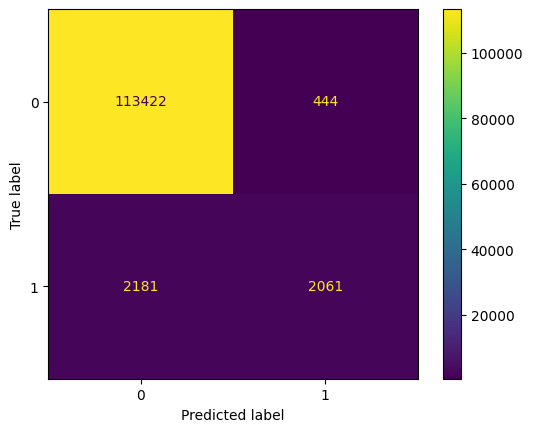

In [ ]:
# Initialize and train the XGBoost model
model = xgb.XGBClassifier(random_state=42)  # You can customize hyperparameters here
model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob = model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred = model.predict(x_val)

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_val, y_pred_prob)
print(f"AUC-ROC score: {auc_roc}")

print(classification_report(y_val, y_pred))

# Simulasi

In [ ]:
import time

# Simulate testing each data point in test_scaled
latency_times = []
for i in range(len(test_scaled)):
    start_time = time.time()
    result_fraud = model.predict(test_scaled.iloc[i:i+1])  # Predict one row at a time
    if result_fraud == 1:
        print(f"Fraud detected at index {i}")
    end_time = time.time()
    latency_times.append(end_time - start_time)

# Calculate and display latency statistics
average_latency = sum(latency_times) / len(latency_times)

len_test = len(test_scaled)
print(f"Model {model.__class__.__name__}")
print(f"Rata2 latency per 1 data: {average_latency:.2f} detik")
print(f"Total latency untuk {len_test} per 1 data: {sum(latency_times):.2f} detik")
print(f"Maksimum latency untuk {len_test} per 1 data: {max(latency_times):.2f} detik")
print(f"Minimum latency untuk {len_test} per 1 data: {min(latency_times):.2f} detik")

In [ ]:
print(f"Model {model.__class__.__name__}")

In [ ]:
import time

# Simulate testing in batches of 100 data points
batch_size = 100
num_batches = len(test_scaled) // batch_size
latency_times = []

for batch_idx in range(num_batches):
    start_time = time.time()
    batch_data = test_scaled.iloc[batch_idx * batch_size:(batch_idx + 1) * batch_size]
    result_fraud = model.predict(batch_data)  # Predict the batch
    end_time = time.time()
    
    # Calculate latency for the batch
    latency_times.append(end_time - start_time)
    print(f"Batch {batch_idx + 1}/{num_batches} processed. Latency: {latency_times[-1]:.6f} seconds")

# Calculate and display overall latency statistics
average_latency = sum(latency_times) / len(latency_times)

print(f"Model {model.__class__.__name__}")
print(f"Rata2 latency per batch (per {batch_size} data): {average_latency:.2f} detik")
print(f"Total latency untuk {num_batches} batch (per {batch_size} data): {sum(latency_times):.2f} detik")
print(f"Maksimum latency untuk {num_batches} batch (per {batch_size} data): {max(latency_times):.2f} detik")
print(f"Minimum latency untuk {num_batches} batch (per {batch_size} data): {min(latency_times):.2f} detik")
print(f"Jumlah batch: {num_batches}")

Model LGBMClassifier
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 1/5066 processed. Latency: 0.026992 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 2/5066 processed. Latency: 0.023003 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 3/5066 processed. Latency: 0.022012 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: fea

In [ ]:
print(f"Rata2 latency per batch (per 100 data): {average_latency:.2f} detik")
print(f"Total latency untuk {num_batches} batch (per 100 data): {sum(latency_times):.2f} detik")
print(f"Maksimum latency untuk {num_batches} batch (per 100 data): {max(latency_times):.2f} detik")
print(f"Minimum latency untuk {num_batches} batch (per 100 data): {min(latency_times):.2f} detik")

Rata2 latency per batch (per 100 data): 0.13 detik
Total latency untuk 5066 batch (per 100 data): 661.14 detik
Maksimum latency untuk 5066 batch (per 100 data): 0.57 detik
Minimum latency untuk 5066 batch (per 100 data): 0.10 detik
Jumlah batch: 5066


In [14]:
# Simulate testing in batches of 100 data points
batch_size = 1000
num_batches = len(test_scaled) // batch_size
latency_times = []

for batch_idx in range(num_batches):
    start_time = time.time()
    batch_data = test_scaled.iloc[batch_idx * batch_size:(batch_idx + 1) * batch_size]
    result_fraud = model.predict(batch_data)  # Predict the batch
    end_time = time.time()
    
    # Calculate latency for the batch
    latency_times.append(end_time - start_time)
    print(f"Batch {batch_idx + 1}/{num_batches} processed. Latency: {latency_times[-1]:.6f} seconds")

# Calculate and display overall latency statistics
average_latency = sum(latency_times) / len(latency_times)
print(f"Model {model.__class__.__name__}")
print(f"Rata2 latency per batch (per {batch_size} data): {average_latency:.2f} detik")
print(f"Total latency untuk {num_batches} batch (per {batch_size} data): {sum(latency_times):.2f} detik")
print(f"Maksimum latency untuk {num_batches} batch (per {batch_size} data): {max(latency_times):.2f} detik")
print(f"Minimum latency untuk {num_batches} batch (per {batch_size} data): {min(latency_times):.2f} detik")
print(f"Jumlah batch: {num_batches}")

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 1/506 processed. Latency: 0.185558 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 2/506 processed. Latency: 0.212610 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 3/506 processed. Latency: 0.203772 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[Light

In [ ]:
# Simulate testing in batches of 100 data points
batch_size = 10000
num_batches = len(test_scaled) // batch_size
latency_times = []

for batch_idx in range(num_batches):
    start_time = time.time()
    batch_data = test_scaled.iloc[batch_idx * batch_size:(batch_idx + 1) * batch_size]
    result_fraud = model.predict(batch_data)  # Predict the batch
    end_time = time.time()
    
    # Calculate latency for the batch
    latency_times.append(end_time - start_time)
    print(f"Batch {batch_idx + 1}/{num_batches} processed. Latency: {latency_times[-1]:.6f} seconds")

# Calculate and display overall latency statistics
average_latency = sum(latency_times) / len(latency_times)
print(f"Rata2 latency per batch (per {batch_size} data): {average_latency:.2f} detik")
print(f"Total latency untuk {num_batches} batch (per {batch_size} data): {sum(latency_times):.2f} detik")
print(f"Maksimum latency untuk {num_batches} batch (per {batch_size} data): {max(latency_times):.2f} detik")
print(f"Minimum latency untuk {num_batches} batch (per {batch_size} data): {min(latency_times):.2f} detik")
print(f"Jumlah batch: {num_batches}")

# Buat Submit Kaggle

In [15]:
isFraud = lgb_model.predict(test_scaled)

# TransactionID = test_transaction['TransactionID']
test_result = pd.DataFrame({'TransactionID': TransactionID, 'isFraud': isFraud})
test_result.to_csv('submission.csv', index=False)
test_result['isFraud'].value_counts()

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


isFraud
0    502347
1      4344
Name: count, dtype: int64

In [34]:
test_result.to_csv('submission.csv', index=False)